# How fast does each part of the model converge? (Cityscapes validation set, 500 images)

## Background

MDEQ is a segmentation model that doesn't have a fixed number of layers. Instead of running a set sequence of layers once, it defines its internal representation as the answer to an equation: find a state `z*` such that applying the network to `z*` gives back `z*` itself (a "fixed point"). It finds that state iteratively, using a solver called Broyden's method, which takes a number of steps (we call this budget `f_thres`) to get closer and closer to the true answer. The model's internal state is split across **4 branches at different resolutions** (scale 0 = finest detail, scale 3 = coarsest), which are combined at every solver step.

This experiment was motivated by an earlier finding on this project: when testing which of these 4 scales actually need to be recomputed for every video frame versus which can safely reuse the answer from the previous frame, **scale 1 turned out to be by far the most important one to recompute properly** — much more so than scale 0. A natural explanation would be that scale 1 is simply the "hardest" of the 4 scales to solve, the one that takes the solver longest to settle on an answer. This notebook tests that idea directly: **does scale 1 actually take the longest to converge to its own fixed point, or is something else going on?**

## What we measure

For 500 Cityscapes validation images, run one at a time (no video, no reuse between frames — just one still image per run), we re-run the solver at every possible budget, `f_thres = 1, 2, 3, ..., 27`, and compare each partial result against the fully-converged answer (`f_thres = 27`, treated as the reference "ground truth" equilibrium for that image). This gives us, for every one of the model's 1320 internal features (spread across the 4 scales), a full curve of how far it still is from its final answer at every step along the way — which lets us directly compare how fast each scale, and each individual feature, actually settles down.

## What this notebook needs

It does **not** load the model, and it never touches the GPU. All of the heavy lifting (running the solver at every budget for all 500 images) was done once by a separate script (`scripts/ml_project/extract_convergence_mse.py`), which takes a few hours to run and saves its results to a single file. This notebook just reads that file and builds the charts below, so it runs in seconds and can be re-executed at any time.

## Roadmap

- **Sections 1-3** set up the data and look at overall convergence speed, per scale.
- **Sections 4-5** turn each channel's convergence curve into a single number, so we can compare speed and consistency channel by channel.
- **Section 6** looks at a quirk of the solver itself that affects how to read some of the later plots.
- **Sections 7-11** dig into individual channels, and check whether the picture changes for the hardest images to solve.

## 1. Load the extraction results

We just need three things: the list of image names, the resulting MSE tensor, and the number of channels per scale (`[88, 176, 352, 704]`, the same fixed architecture constant used throughout this project). That last one is hardcoded rather than read off the model, since we're not loading it here.

In [1]:
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

MDEQ_VISION_ROOT = Path("../..").resolve()
RESULTS_PATH = MDEQ_VISION_ROOT / "results/ml_project/convergence_mse_all_images.pt"

results = torch.load(RESULTS_PATH, map_location="cpu", weights_only=False)
image_names = results["image_names"]
mse_stack = torch.stack(results["mse"])  # (num_images, 27, 1320)

F_THRES_VALUES = list(range(1, mse_stack.shape[1] + 1))
SCALE_CHANNELS = [88, 176, 352, 704]
boundaries = np.cumsum([0] + SCALE_CHANNELS)
colors = plt.cm.viridis(np.linspace(0, 0.85, 4))

print(f"{len(image_names)} images loaded from {RESULTS_PATH.name}")
print("mse_stack shape (num_images, f_thres, channels):", tuple(mse_stack.shape))
print("mean MSE at f_thres=27 across all images (sanity check, should be ~0):",
      mse_stack[:, -1, :].mean().item())

500 images loaded from convergence_mse_all_images.pt
mse_stack shape (num_images, f_thres, channels): (500, 27, 1320)
mean MSE at f_thres=27 across all images (sanity check, should be ~0): 0.0


All 500 images are in, and the sanity check passes: the mean MSE at `f_thres=27` is exactly 0. That's expected, `f_thres=27` is the same computation used to define each image's own reference equilibrium, so comparing it to itself has to land on exactly zero.

## 2. Convergence speed per scale, across the validation set

For each image, we average the error (mean squared error, or MSE, against that image's own reference equilibrium) over all the channels within a scale, giving one number per image per `f_thres`. Plotting the median across all 500 images, together with a 10th-90th percentile band, tells us whether "some scales converge faster than others" is a consistent, stable property of the model, or whether the ranking of scales jumps around depending on the image.

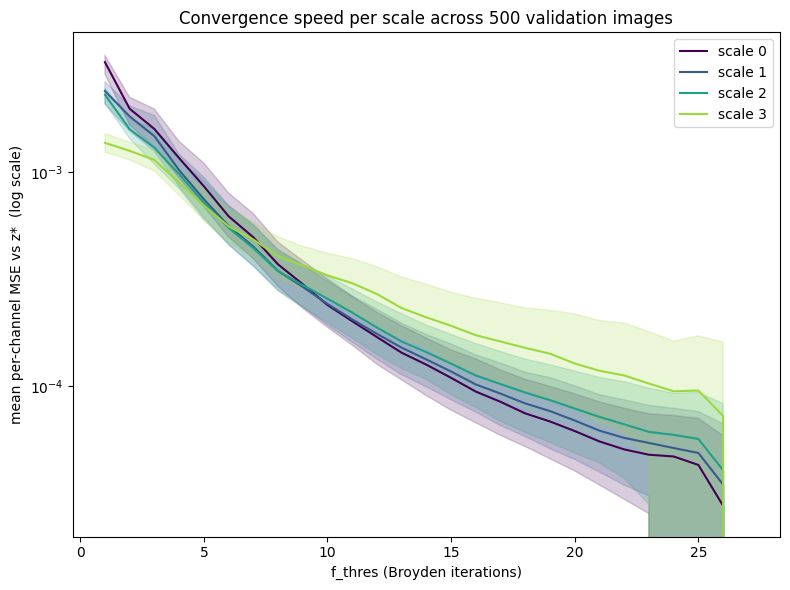

In [2]:
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(4):
    block = mse_stack[:, :, boundaries[i]:boundaries[i + 1]]  # (num_images, 27, channels_i)
    per_image_scale_avg = block.mean(dim=2).numpy()  # (num_images, 27): one curve per image

    median = np.median(per_image_scale_avg, axis=0)
    p10, p90 = np.percentile(per_image_scale_avg, [10, 90], axis=0)
    ax.plot(F_THRES_VALUES, median, color=colors[i], label=f"scale {i}")
    ax.fill_between(F_THRES_VALUES, p10, p90, color=colors[i], alpha=0.2)

ax.set_yscale("log")
ax.set_xlabel("f_thres (Broyden iterations)")
ax.set_ylabel("mean per-channel MSE vs z*  (log scale)")
ax.set_title(f"Convergence speed per scale across {mse_stack.shape[0]} validation images")
ax.legend()
ax.minorticks_off()
plt.tight_layout()
plt.show()

The ranking is consistent, not a coincidence of one image. Scale 0 is reliably the fastest and scale 3 the slowest across the whole 500-image set, with scale 3 visibly pulling away from the other three starting around `f_thres≈8`.

## 3. Per-channel spread within each scale, averaged over images

Section 2 averaged over channels *and* images, which can hide a lot: a scale could look fast on average while actually containing a handful of very slow channels dragging up the mean. To check, we first average each channel's own trajectory over all 500 images (removing image-to-image noise), then plot the median plus a 10th-90th percentile band **across channels**, one panel per scale, so we can see how much channels within the same scale actually agree with each other.

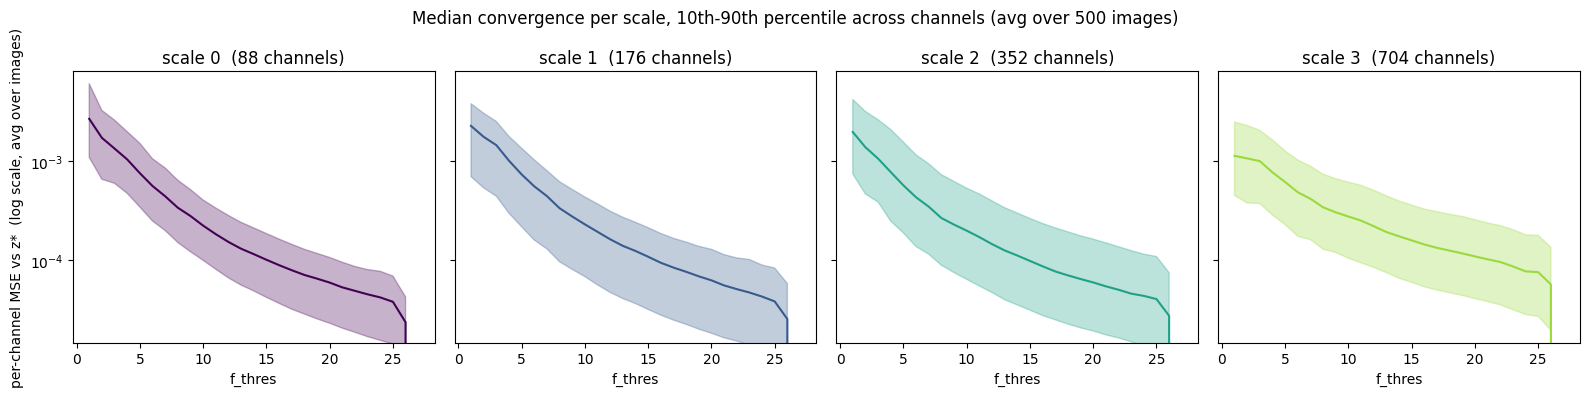

In [3]:
channel_avg_over_images = mse_stack.mean(dim=0).numpy()  # (27, 1320): each channel's trajectory, avg over images

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for i, ax in enumerate(axes):
    block = channel_avg_over_images[:, boundaries[i]:boundaries[i + 1]]  # (27, channels_i)
    p10, p50, p90 = np.percentile(block, [10, 50, 90], axis=1)
    ax.plot(F_THRES_VALUES, p50, color=colors[i])
    ax.fill_between(F_THRES_VALUES, p10, p90, color=colors[i], alpha=0.3)
    ax.set_yscale("log")
    ax.set_title(f"scale {i}  ({block.shape[1]} channels)")
    ax.set_xlabel("f_thres")
    ax.minorticks_off()

axes[0].set_ylabel("per-channel MSE vs z*  (log scale, avg over images)")
fig.suptitle(f"Median convergence per scale, 10th-90th percentile across channels (avg over {mse_stack.shape[0]} images)")
plt.tight_layout()
plt.show()

The wide channel-to-channel spread inside every scale doesn't average away, it's still there with 500 images behind it. That's a useful confirmation: it means "how fast a scale converges on average" and "how consistent its channels are" are two genuinely different, structural properties of the model, not noise from a single image.

## 4. Distribution of convergence speed per scale, averaged over images

A curve per scale is useful, but it still doesn't tell us how individual channels behave. So here we reduce each channel's image-averaged trajectory to a single number, the smallest `f_thres` at which its error first drops below 10% of what it was at `f_thres=1`, and scatter that number per channel, grouped by scale. We use 10% rather than a stricter cutoff like 1%, because a stricter threshold mostly ends up measuring which channels happen to hit the solver's own exact-convergence cliff (Section 6 explains this in more detail), which collapses almost every channel to the same last couple of iterations and isn't very informative. 10% spreads the distribution out in a way that's actually readable.

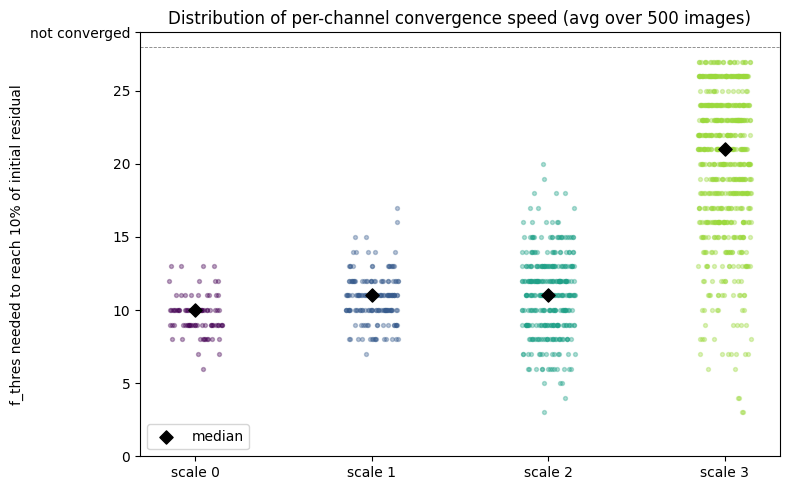

scale 0: median iters-to-converge = 10.0  | 0/88 channels never reached the threshold
scale 1: median iters-to-converge = 11.0  | 0/176 channels never reached the threshold
scale 2: median iters-to-converge = 11.0  | 0/352 channels never reached the threshold
scale 3: median iters-to-converge = 21.0  | 0/704 channels never reached the threshold


In [4]:
CONVERGE_THRESHOLD = 0.1
relative_mse = channel_avg_over_images / channel_avg_over_images[0:1, :]  # normalize by each channel's f_thres=1 value


def first_below(row, threshold):
    idx = np.where(row < threshold)[0]
    return F_THRES_VALUES[idx[0]] if len(idx) else np.nan


iters_to_converge = np.array(
    [first_below(relative_mse[:, c], CONVERGE_THRESHOLD) for c in range(relative_mse.shape[1])]
)
not_converged = np.isnan(iters_to_converge)
NOT_CONVERGED_Y = len(F_THRES_VALUES) + 2
plot_y = np.where(not_converged, NOT_CONVERGED_Y, iters_to_converge)

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(8, 5))
for i in range(4):
    sl = slice(boundaries[i], boundaries[i + 1])
    y = plot_y[sl]
    x = i + rng.uniform(-0.15, 0.15, size=len(y))
    ax.scatter(x, y, s=8, alpha=0.35, color=colors[i])
    ax.scatter(i, np.median(y), color="black", marker="D", s=45, zorder=5, label="median" if i == 0 else None)

ax.axhline(NOT_CONVERGED_Y - 1, color="gray", lw=0.6, ls="--")
ax.set_xticks(range(4))
ax.set_xticklabels([f"scale {i}" for i in range(4)])
max_ft = len(F_THRES_VALUES)
ax.set_yticks(list(range(0, max_ft + 1, 5)) + [NOT_CONVERGED_Y])
ax.set_yticklabels([str(v) for v in range(0, max_ft + 1, 5)] + ["not converged"])
ax.set_ylabel(f"f_thres needed to reach {int(CONVERGE_THRESHOLD * 100)}% of initial residual")
ax.set_title(f"Distribution of per-channel convergence speed (avg over {mse_stack.shape[0]} images)")
ax.legend()
plt.tight_layout()
plt.show()

for i in range(4):
    sl = slice(boundaries[i], boundaries[i + 1])
    n_not_converged = int(not_converged[sl].sum())
    print(f"scale {i}: median iters-to-converge = {np.nanmedian(iters_to_converge[sl]):.1f}  "
          f"| {n_not_converged}/{sl.stop - sl.start} channels never reached the threshold")

Median iterations needed to reach 10%: **10 for scale 0, 11 for scale 1, 11 for scale 2, and 21 for scale 3**. Scale 3 stands out clearly, needing roughly twice as many iterations as the other three. Every single channel in every scale eventually crosses the threshold (0 out of 1320 fail to), so this is purely a story about *how long channels take*, not about some of them never converging at all.

## 5. Is convergence speed a fixed property of a channel, or does it depend on the image?

Everything above averages over images *before* computing anything else. Here we flip that around: for each channel, we compute "iterations to reach 10% of `f_thres=1`" **separately for every one of the 500 images**, and then look at how much that number varies from image to image (its standard deviation). A channel with low spread converges at roughly the same speed no matter what's in the frame; a channel with high spread is context-dependent: sometimes fast, sometimes slow, depending on what it's looking at. Running this on 500 different images is exactly what makes the question answerable: a single image could never distinguish "this channel is always this speed" from "this channel just happened to be this speed here."

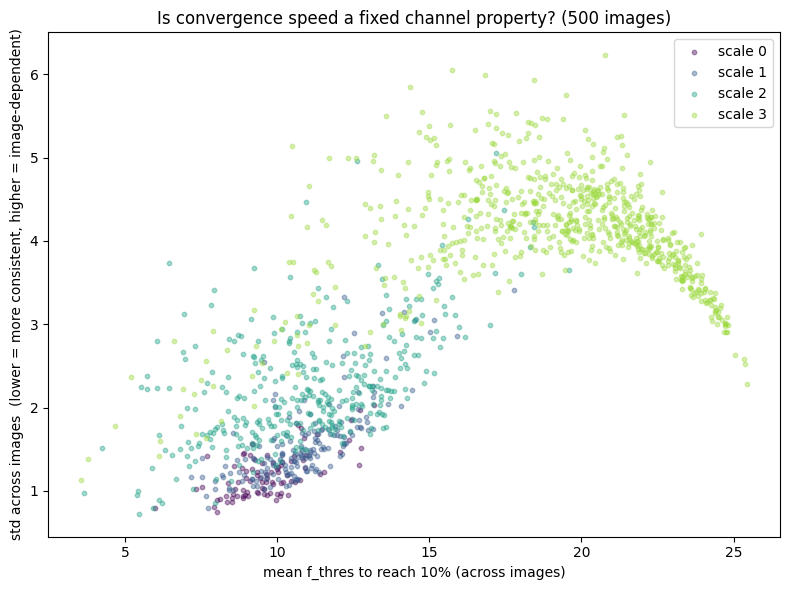

scale 0: median std across images = 1.14 iterations
scale 1: median std across images = 1.45 iterations
scale 2: median std across images = 2.18 iterations
scale 3: median std across images = 4.16 iterations


In [5]:
mse_np = mse_stack.numpy()  # (num_images, 27, 1320)
f_thres_arr = np.array(F_THRES_VALUES)

relative_per_image = mse_np / mse_np[:, 0:1, :]  # each image normalized by its own f_thres=1 value, per channel
below_threshold = relative_per_image < CONVERGE_THRESHOLD  # (num_images, 27, 1320)

first_idx = np.argmax(below_threshold, axis=1)  # (num_images, 1320): index of first True (0 if none found)
ever_converged = below_threshold.any(axis=1)  # (num_images, 1320)
iters_per_image = np.where(ever_converged, f_thres_arr[first_idx], np.nan)  # (num_images, 1320)

mean_iters = np.nanmean(iters_per_image, axis=0)  # (1320,)
std_iters = np.nanstd(iters_per_image, axis=0)  # (1320,): consistency across images

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(4):
    sl = slice(boundaries[i], boundaries[i + 1])
    ax.scatter(mean_iters[sl], std_iters[sl], s=10, alpha=0.4, color=colors[i], label=f"scale {i}")

ax.set_xlabel(f"mean f_thres to reach {int(CONVERGE_THRESHOLD * 100)}% (across images)")
ax.set_ylabel("std across images  (lower = more consistent, higher = image-dependent)")
ax.set_title(f"Is convergence speed a fixed channel property? ({mse_stack.shape[0]} images)")
ax.legend()
plt.tight_layout()
plt.show()

for i in range(4):
    sl = slice(boundaries[i], boundaries[i + 1])
    print(f"scale {i}: median std across images = {np.nanmedian(std_iters[sl]):.2f} iterations")

The median standard deviation across images rises with the scale: **1.14 iterations for scale 0, 1.45 for scale 1, 2.18 for scale 2, and 4.16 for scale 3**. So it isn't just that scale 3 is the slowest scale, it's also the least predictable one, more than three times as variable as scale 0. Speed and consistency go hand in hand here: the fast scales are also the reliable ones, and the slow scale is also the unpredictable one.

## 6. When does each image's solver stop early?

This came up while interpreting Section 3: the "cutoff" visible near `f_thres=25-26` in those panels isn't really telling us anything about individual scales. Broyden solves all 4 scales as **one concatenated vector**, so its early-stopping rule fires for all 4 at the same time, for a given image (it's just that *which* `f_thres` that happens at varies from image to image). This histogram shows that variation directly: for each image, the first `f_thres` at which its state becomes exactly identical to z\* (MSE = 0.0).

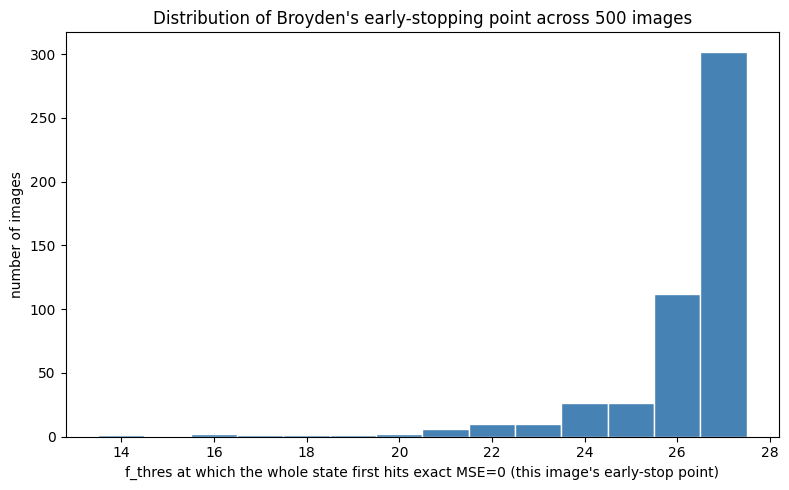

min=14, max=27, median=27.0, mean=26.1


In [6]:
scale0_block = mse_stack[:, :, boundaries[0]:boundaries[1]].numpy()  # (num_images, 27, 88); any scale gives the same result
is_zero = (scale0_block.sum(axis=2) == 0.0)  # (num_images, 27)
first_exact_zero = np.array([np.where(row)[0][0] + 1 if row.any() else np.nan for row in is_zero])

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.arange(np.nanmin(first_exact_zero) - 0.5, np.nanmax(first_exact_zero) + 1.5, 1)
ax.hist(first_exact_zero, bins=bins, color="steelblue", edgecolor="white")
ax.set_xlabel("f_thres at which the whole state first hits exact MSE=0 (this image's early-stop point)")
ax.set_ylabel("number of images")
ax.set_title(f"Distribution of Broyden's early-stopping point across {mse_stack.shape[0]} images")
plt.tight_layout()
plt.show()

print(f"min={int(np.nanmin(first_exact_zero))}, max={int(np.nanmax(first_exact_zero))}, "
      f"median={np.nanmedian(first_exact_zero):.1f}, mean={np.nanmean(first_exact_zero):.1f}")

The earliest exact stop across the whole set is `f_thres=14`, the latest is `f_thres=27` (the budget cap itself), and the median is 27 meaning the *majority* of images never trigger Broyden's own convergence rule at all within the 27-iteration budget; they simply run out of budget still (slightly) improving. Only a minority stop early. Section 10 picks this up again, comparing the two groups directly.

## 7. Convergence rate per channel (threshold-free)

Section 4 reduced each channel to "iterations to reach 10% of `f_thres=1`", a single snapshot along the decay, and a somewhat arbitrary one (why 10% and not 5%?). Here's a version that isn't a snapshot at all: we fit a straight line to `log10(MSE)` vs. `f_thres` for each channel and use its **slope** as the convergence rate (how many orders of magnitude the error drops per iteration). This is a continuous rate rather than a single point on the curve.

The fit only uses `f_thres = 1` through `10`, safely before Section 6's earliest early-stopping point (14), so no image's exact-zero cliff can contaminate it. We flip the sign for the plot (`decay rate = -slope`) so that **higher means faster**, which matches how most people intuitively read a "rate" (the opposite convention from Section 4, where higher meant *slower*, so it's worth keeping that in mind when comparing the two).

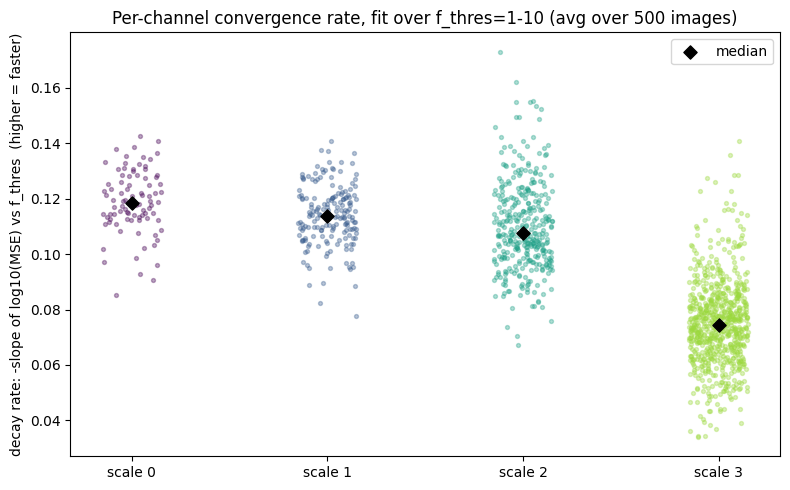

scale 0: median decay rate = 0.118 log10-units/iteration
scale 1: median decay rate = 0.114 log10-units/iteration
scale 2: median decay rate = 0.107 log10-units/iteration
scale 3: median decay rate = 0.075 log10-units/iteration


In [7]:
FIT_START, FIT_END = 1, 10  # f_thres range used for the fit (see markdown for why)
fit_indices = [F_THRES_VALUES.index(ft) for ft in range(FIT_START, FIT_END + 1)]
x_fit = np.array(F_THRES_VALUES)[fit_indices]

decay_rate = np.zeros(channel_avg_over_images.shape[1])
for c in range(channel_avg_over_images.shape[1]):
    y_fit = np.log10(channel_avg_over_images[fit_indices, c])
    slope, _intercept = np.polyfit(x_fit, y_fit, 1)
    decay_rate[c] = -slope  # flip sign: higher = faster (see markdown)

fig, ax = plt.subplots(figsize=(8, 5))
rng = np.random.default_rng(0)
for i in range(4):
    sl = slice(boundaries[i], boundaries[i + 1])
    y = decay_rate[sl]
    x = i + rng.uniform(-0.15, 0.15, size=len(y))
    ax.scatter(x, y, s=8, alpha=0.35, color=colors[i])
    ax.scatter(i, np.median(y), color="black", marker="D", s=45, zorder=5, label="median" if i == 0 else None)

ax.set_xticks(range(4))
ax.set_xticklabels([f"scale {i}" for i in range(4)])
ax.set_ylabel("decay rate: -slope of log10(MSE) vs f_thres  (higher = faster)")
ax.set_title(f"Per-channel convergence rate, fit over f_thres={FIT_START}-{FIT_END} (avg over {mse_stack.shape[0]} images)")
ax.legend()
plt.tight_layout()
plt.show()

for i in range(4):
    sl = slice(boundaries[i], boundaries[i + 1])
    print(f"scale {i}: median decay rate = {np.median(decay_rate[sl]):.3f} log10-units/iteration")

Median decay rate per scale: **0.118 (scale 0), 0.114 (scale 1), 0.107 (scale 2), 0.075 (scale 3)**, the same ordering we've seen in every metric so far, now expressed as a genuine rate rather than a threshold crossing. Scale 0 sheds error about 57% faster per iteration than scale 3 does (0.118 vs. 0.075).

## 8. Look at one individual channel

Everything above summarizes across channels. Sometimes it helps to just look at *one*, say, channel 0 (the first channel of scale 0), or whichever channel stood out as a fast or slow outlier in Sections 4 or 7. `channel_to_scale(c)` translates a global channel index (0-1319, the same order used everywhere in this project) into its `(scale, local index within that scale)`.

`plot_channel(c)` plots that one channel's MSE trajectory for all 500 images at once; thin, transparent lines, individually noisy, but their density shows where most images sit, plus a bold black line for the average, the same curve Sections 3, 4 and 7 are built from.

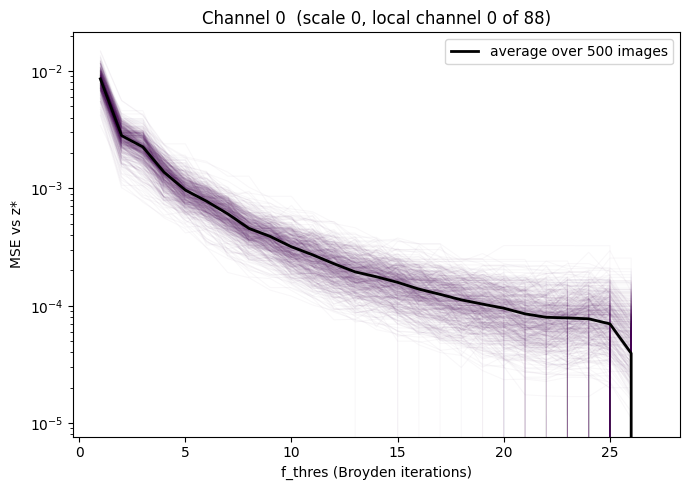

slowest channel: 1081  (scale 3, rate=0.034)
fastest channel: 606  (scale 2, rate=0.173)


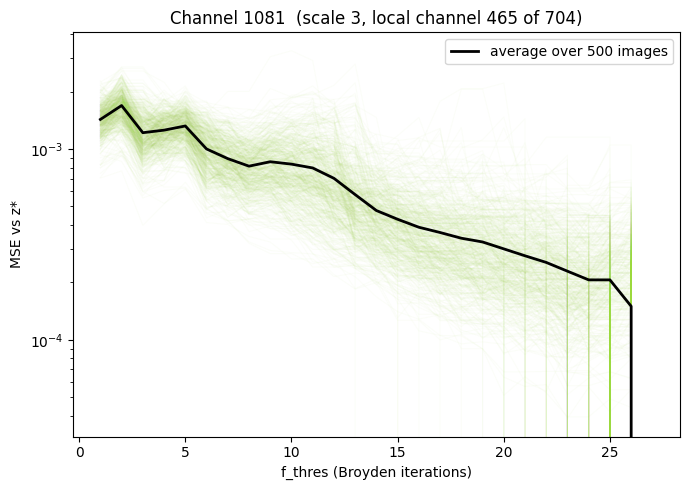

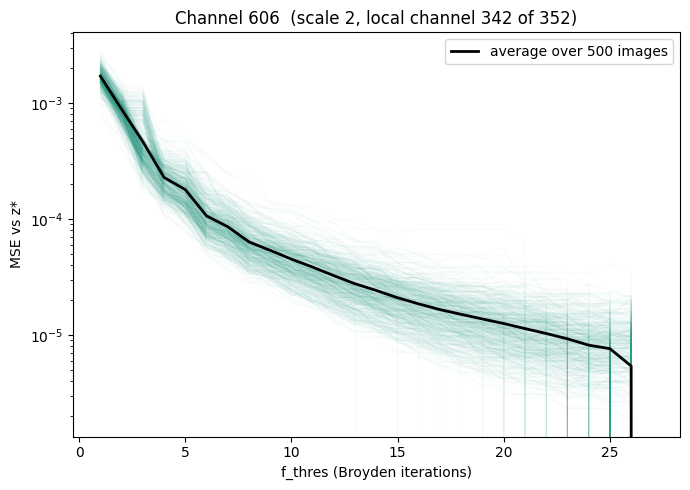

In [8]:
def channel_to_scale(channel_idx):
    """Global channel index (0-1319) -> (scale, local index within that scale)."""
    scale = int(np.searchsorted(boundaries, channel_idx, side="right") - 1)
    local_idx = channel_idx - boundaries[scale]
    return scale, local_idx


def plot_channel(channel_idx):
    scale, local_idx = channel_to_scale(channel_idx)
    fig, ax = plt.subplots(figsize=(7, 5))

    for n in range(mse_stack.shape[0]):  # one thin line per image
        ax.plot(F_THRES_VALUES, mse_stack[n, :, channel_idx].numpy(), color=colors[scale], alpha=0.03, lw=0.8)
    ax.plot(F_THRES_VALUES, channel_avg_over_images[:, channel_idx], color="black", lw=2,
            label=f"average over {mse_stack.shape[0]} images")

    ax.set_yscale("log")
    ax.set_xlabel("f_thres (Broyden iterations)")
    ax.set_ylabel("MSE vs z*")
    ax.set_title(f"Channel {channel_idx}  (scale {scale}, local channel {local_idx} of {SCALE_CHANNELS[scale]})")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_channel(0)  # the first channel of scale 0

# Two more interesting ones for free: the single fastest- and slowest-decaying channels from Section 7.
slowest_channel = int(np.argmin(decay_rate))
fastest_channel = int(np.argmax(decay_rate))
print(f"slowest channel: {slowest_channel}  (scale {channel_to_scale(slowest_channel)[0]}, "
      f"rate={decay_rate[slowest_channel]:.3f})")
print(f"fastest channel: {fastest_channel}  (scale {channel_to_scale(fastest_channel)[0]}, "
      f"rate={decay_rate[fastest_channel]:.3f})")
plot_channel(slowest_channel)
plot_channel(fastest_channel)

The single slowest channel across the whole dataset is channel 1081, in scale 3 (rate 0.034) — consistent with scale 3 being the slowest scale overall. But the single *fastest* channel, 606, actually belongs to scale 2, not scale 0 (rate 0.173). A reminder that scale 0 wins on average, not because every one of its channels is individually the fastest.

## 9. Every channel's average curve, overlaid in one plot

Section 8 let us look at one channel at a time. Here's all of them at once for a given scale, as a single plot with one line per channel (the average over 500 images). Lines are colored by that channel's own convergence rate from Section 7, from slowest (dark) to fastest (yellow).

Plotting raw MSE this way turned out to be hard to read, because channels differ a lot in their own activation scale, so the overlay ended up being mostly about vertical position rather than shape. Normalizing each channel by its own `f_thres=1` value (the same `relative_mse` from Section 4) fixes that: every curve now starts at 1.0 and fans out downward at its own rate, so the shapes become directly comparable and the coloring lines up much better with what you actually see.

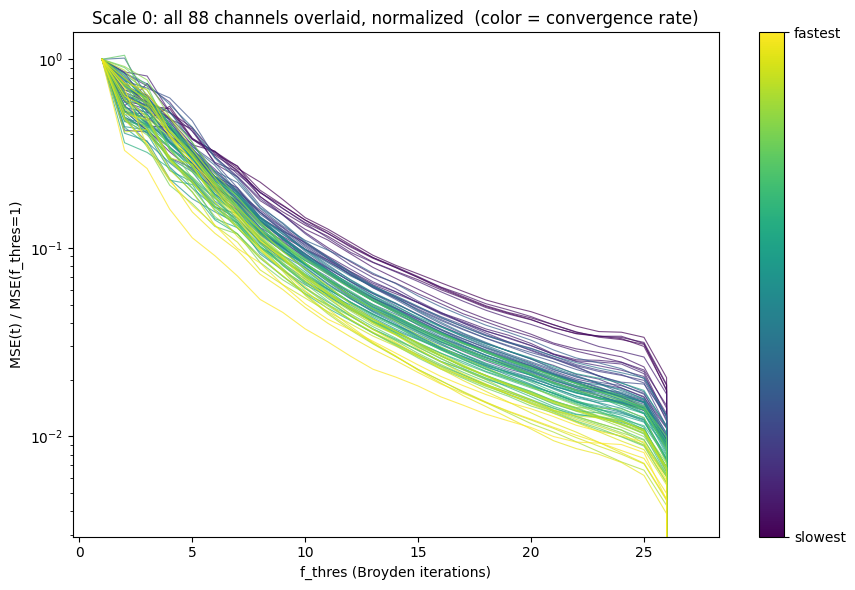

In [9]:
def plot_all_channels_overlaid(scale_i, normalize=True, avg_data=None, relative_data=None, title_extra=""):
    avg_data = channel_avg_over_images if avg_data is None else avg_data
    relative_data = relative_mse if relative_data is None else relative_data
    data = relative_data if normalize else avg_data

    start, end = boundaries[scale_i], boundaries[scale_i + 1]
    n_channels = end - start
    cmap = plt.cm.viridis

    # Ordering/coloring always comes from the full-dataset decay_rate (Section 7), even when the data
    # being plotted is a subset -- so a given channel keeps the same color across different plots.
    order = np.argsort(decay_rate[start:end])
    fig, ax = plt.subplots(figsize=(9, 6))
    for rank, local_idx in enumerate(order):
        global_idx = start + local_idx
        color = cmap(rank / max(n_channels - 1, 1))
        ax.plot(F_THRES_VALUES, data[:, global_idx], color=color, lw=0.8, alpha=0.7)

    ax.set_yscale("log")
    ax.set_xlabel("f_thres (Broyden iterations)")
    if normalize:
        ax.set_ylabel("MSE(t) / MSE(f_thres=1)")
        ax.set_title(f"Scale {scale_i}: all {n_channels} channels overlaid, normalized{title_extra}  "
                     f"(color = convergence rate)")
    else:
        ax.set_ylabel("MSE vs z*  (avg over images)")
        ax.set_title(f"Scale {scale_i}: all {n_channels} channels overlaid, raw MSE{title_extra}  "
                     f"(color = convergence rate)")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, ticks=[0, 1])
    cbar.ax.set_yticklabels(["slowest", "fastest"])
    plt.tight_layout()
    plt.show()


plot_all_channels_overlaid(0)

The color now lines up with height the way you'd expect — the darkest (slowest) lines sit at the top of the fan, the yellow (fastest) ones fall furthest, since normalizing removed the activation-scale differences that used to blur that relationship.

## 10. Same view, restricted to the images that never triggered early stopping

Section 6 found that about 300 of the 500 images never trigger Broyden's own convergence rule within the 27-iteration budget; the other roughly 200 stop early, somewhere between `f_thres=14` and `26`. The 300 that use the full budget are presumably the "harder" cases for the solver. Does the per-channel picture from Section 9 look any different if we only average over that subset, instead of all 500 images?

Colors are kept from the full-dataset decay rate (Section 7) on purpose, so a given channel has the same color in both plots. That makes it easy to spot whether a channel that looked fast or slow overall still looks that way among just the hard images.

302 / 500 images never triggered early stopping (used the full 27-iteration budget)


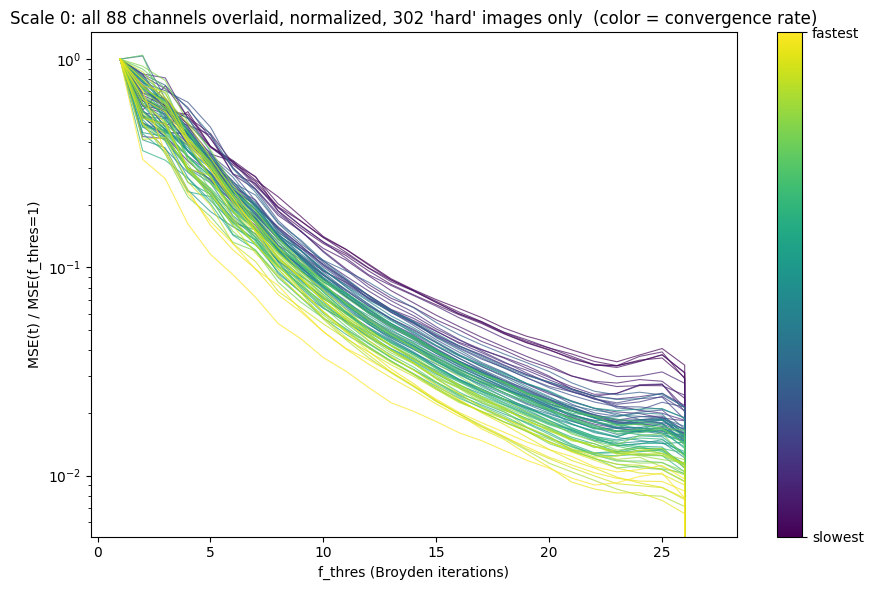

In [10]:
hard_mask = torch.from_numpy(first_exact_zero == 27)
n_hard = int(hard_mask.sum())
print(f"{n_hard} / {mse_stack.shape[0]} images never triggered early stopping (used the full 27-iteration budget)")

channel_avg_hard = mse_stack[hard_mask].mean(dim=0).numpy()  # (27, 1320), averaged over just these images
relative_mse_hard = channel_avg_hard / channel_avg_hard[0:1, :]

plot_all_channels_overlaid(0, avg_data=channel_avg_hard, relative_data=relative_mse_hard,
                            title_extra=f", {n_hard} 'hard' images only")

302 of the 500 images fall in this "hard" group. The overall picture doesn't change (same fan shape, same ordering of fast vs. slow channels) but a small upward bump appears around `f_thres≈22-25` in several of the slower curves, more visible here than in the full-500 average. That's a reasonable thing to see: these are specifically the images where the solver is still actively correcting late in the budget, so any last-minute wobble in Broyden's update shows up more clearly once we're not averaging it together with the 200 "easy" images that already settled down earlier.

## 11. Same two views, for scales 1, 2 and 3

Sections 9 and 10 covered scale 0: the full 500-image average, and the 302 "hard" images that never triggered Broyden's early stop. Here's the same pair of plots for the remaining three scales: `channel_avg_hard` and `relative_mse_hard` were already computed over all 1320 channels in Section 10, so there's nothing left to recompute, just call `plot_all_channels_overlaid` again with each scale's index.

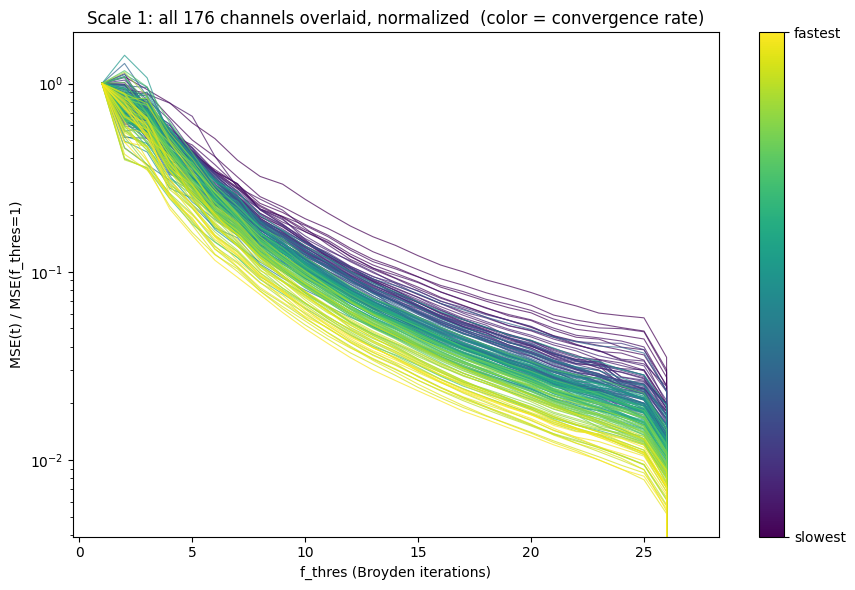

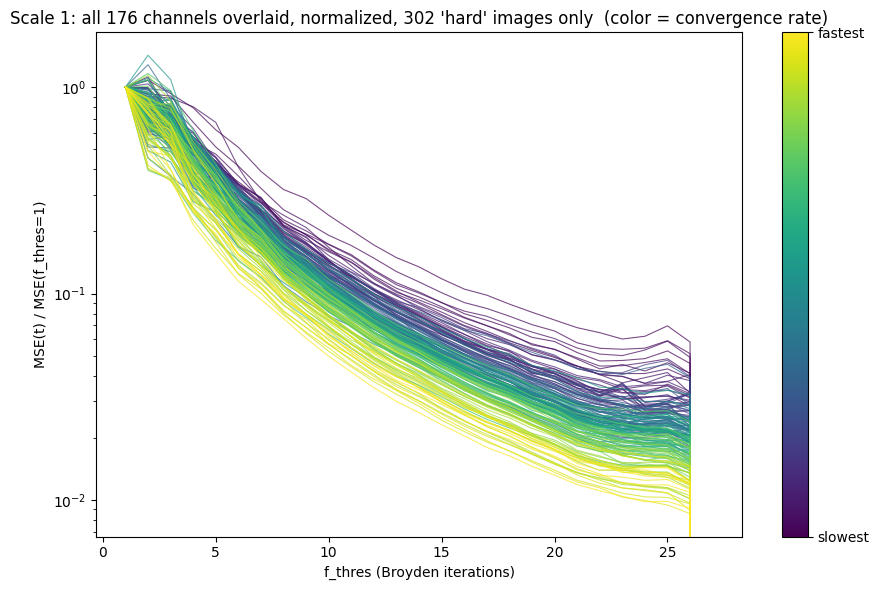

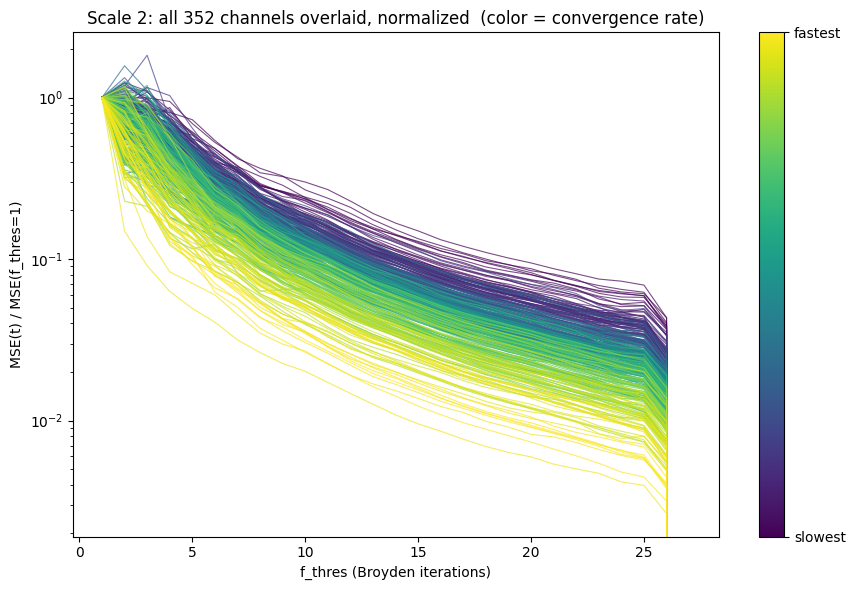

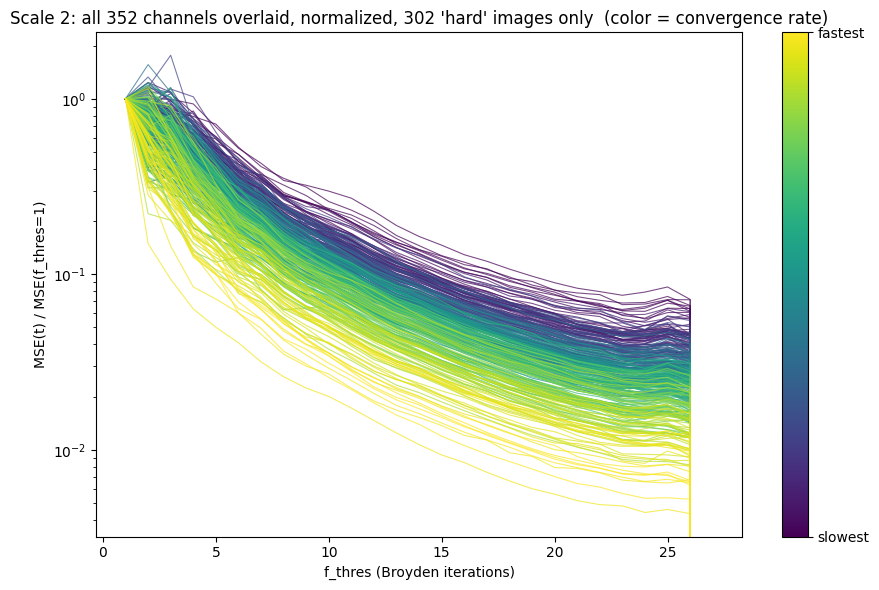

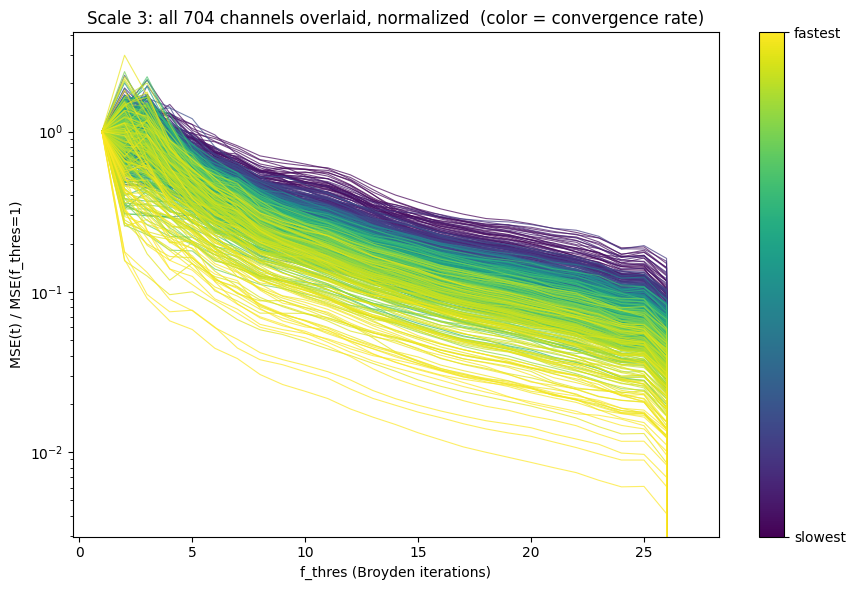

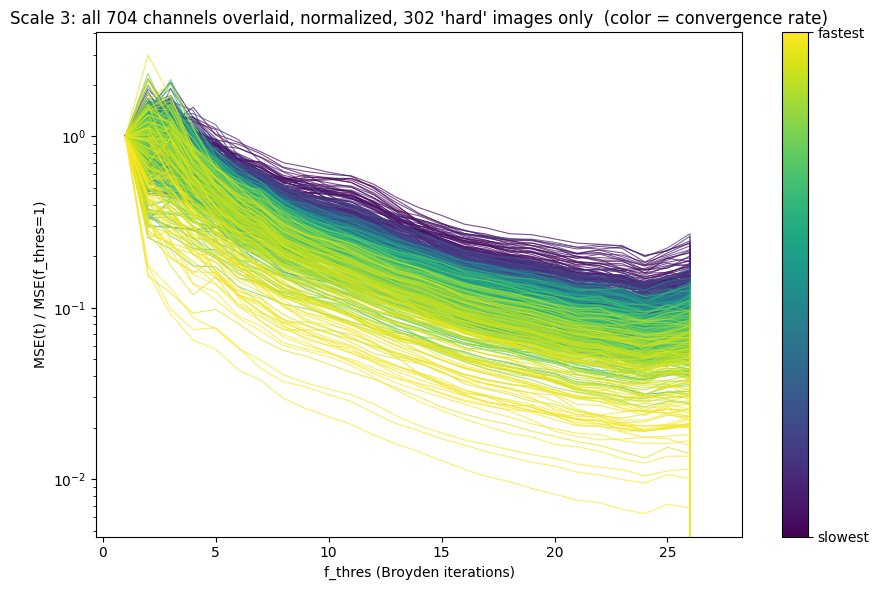

In [11]:
for scale_i in [1, 2, 3]:
    plot_all_channels_overlaid(scale_i)
    plot_all_channels_overlaid(scale_i, avg_data=channel_avg_hard, relative_data=relative_mse_hard,
                                title_extra=f", {n_hard} 'hard' images only")

Scales 1 and 2 look broadly similar to scale 0 — a reasonably tight fan of curves. Scale 3 stands apart, the same way it did in every earlier section: its slowest channels barely drop below 15-20% of their starting value across the whole run (compared to a couple of percent for the other scales), and the initial upward bump before the real decay begins is much more pronounced here too.

## Overall summary

Across every way of slicing the full 500-image validation set, a clear and consistent picture emerges:

- **Scale 0 is the fastest scale to converge, and the most consistent one**: low spread across channels (Section 3), low variability from image to image (Section 5), the highest decay rate (Section 7).
- **Scale 3 is the slowest, and the least predictable**: needs roughly twice as many iterations as the others to reach 10% of its starting error (Section 4), is more than 3x as variable across images as scale 0 (Section 5), and shows the clearest sign of the solver's update overshooting before it settles down (Sections 10-11).
- Speed and consistency travel together: the scales that converge fastest are also the ones whose behavior is most predictable from one image to the next.
- **Scale 1 is unremarkable on every one of these measures** — it sits in the middle of the ranking, never the fastest or the slowest, and never the most or least predictable.

That last point is the one this whole experiment was built to check. Scale 1 was already known, from separate experiments on this project, to be by far the most valuable scale to keep warm-started across video frames — far more than scale 0. If that were simply because scale 1 is the "hardest" scale to solve from scratch, we'd expect it to show up here as the slowest or most erratic one. It doesn't. So whatever makes scale 1 valuable isn't about it being intrinsically difficult to solve on its own — it's more likely about how much its state shapes the other three scales once everything gets fused back together at each solver step, which points to the model's internal fusion mechanism as the more promising place to look next, rather than any single scale's raw convergence speed.